# Week 4 — ECG Feature Extraction

This notebook uses NeuroKit2 to detect R-peaks, calculate RR intervals, heart rate and HRV features, compute an ECG power spectrum, and extract features from SaMi-Trop and PTB-XL records.


In [1]:
import glob
import warnings

import wfdb
import neurokit2 as nk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import periodogram, resample_poly

warnings.filterwarnings("ignore")

print("NeuroKit2 version:", nk.__version__)


NeuroKit2 version: 0.2.13


## Find available ECG records

In [2]:
ptb_records = sorted(
    path[:-4]
    for path in glob.glob(
        "data/ptbxl_wfdb/**/*.hea",
        recursive=True
    )
)

sami_records = sorted(
    path[:-4]
    for path in glob.glob(
        "data/samitrop_wfdb/**/*.hea",
        recursive=True
    )
)

print("PTB-XL negative records:", len(ptb_records))
print("SaMi-Trop positive records:", len(sami_records))

if ptb_records:
    print("Example PTB-XL record:", ptb_records[0])

if sami_records:
    print("Example SaMi-Trop record:", sami_records[0])


PTB-XL negative records: 166
SaMi-Trop positive records: 1631
Example PTB-XL record: data/ptbxl_wfdb/00000/00001_hr
Example SaMi-Trop record: data/samitrop_wfdb/100726


## Load one ECG and detect R-peaks

In [3]:
if not ptb_records:
    raise FileNotFoundError(
        "No prepared PTB-XL records found in data/ptbxl_wfdb."
    )

example_path = ptb_records[0]
record = wfdb.rdrecord(example_path)

signals = np.asarray(record.p_signal, dtype=float)
fs = int(record.fs)
lead_names = list(record.sig_name)

lead_index = (
    lead_names.index("II")
    if "II" in lead_names
    else min(1, signals.shape[1] - 1)
)

lead = signals[:, lead_index]

valid = np.isfinite(lead)

if valid.sum() == 0:
    raise ValueError("The selected lead contains no valid values.")

if not np.all(valid):
    lead = np.interp(
        np.arange(len(lead)),
        np.flatnonzero(valid),
        lead[valid]
    )

time = np.arange(len(lead)) / fs

print("Record:", example_path)
print("Sampling frequency:", fs)
print("Selected lead:", lead_names[lead_index])
print("Signal length:", len(lead))


Record: data/ptbxl_wfdb/00000/00001_hr
Sampling frequency: 500
Selected lead: II
Signal length: 5000


Detected R-peaks: 10


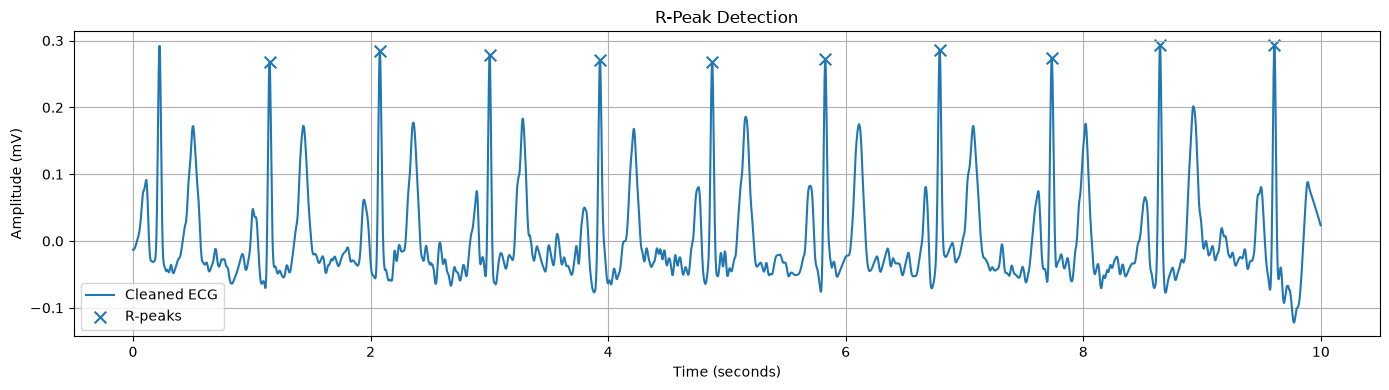

In [4]:
cleaned = nk.ecg_clean(
    lead,
    sampling_rate=fs,
    method="neurokit"
)

_, peak_info = nk.ecg_peaks(
    cleaned,
    sampling_rate=fs,
    method="neurokit"
)

rpeaks = np.asarray(
    peak_info["ECG_R_Peaks"],
    dtype=int
)

print("Detected R-peaks:", len(rpeaks))

plt.figure(figsize=(14, 4))
plt.plot(time, cleaned, label="Cleaned ECG")

plt.scatter(
    rpeaks / fs,
    cleaned[rpeaks],
    marker="x",
    s=70,
    label="R-peaks"
)

plt.title("R-Peak Detection")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


The markers should appear on the main QRS peaks. The plot should be inspected visually to confirm that the detections look correct.

## RR intervals, instantaneous heart rate and HRV

,RR_interval_ms,Instantaneous_HR_bpm
0,928.0,64.655172
1,924.0,64.935065
2,930.0,64.516129
3,944.0,63.559322
4,952.0,63.025210
5,964.0,62.240664
6,942.0,63.694268
7,912.0,65.789474
8,962.0,62.370062


Mean RR: 939.78 ms
Mean heart rate: 63.84 bpm
SDNN: 17.70 ms
RMSSD: 23.29 ms


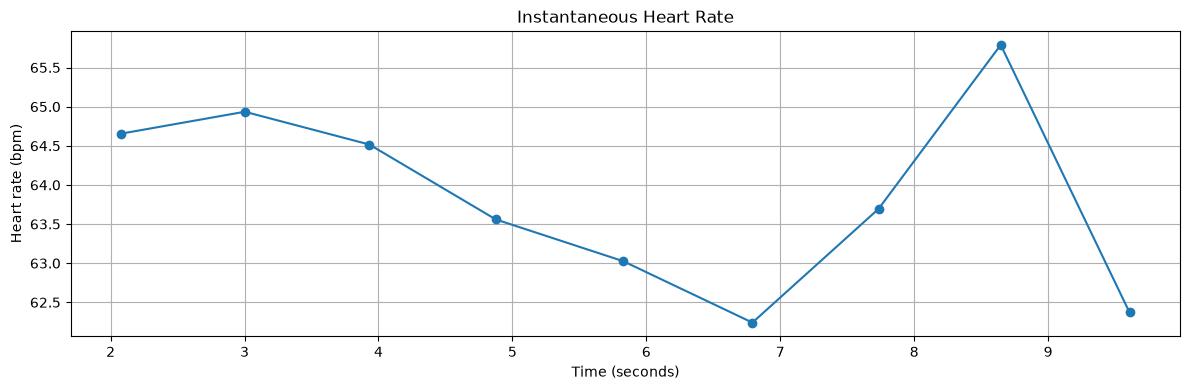

In [5]:
if len(rpeaks) >= 2:
    rr_intervals_ms = np.diff(rpeaks) / fs * 1000
    instantaneous_hr = 60000 / rr_intervals_ms

    rr_table = pd.DataFrame({
        "RR_interval_ms": rr_intervals_ms,
        "Instantaneous_HR_bpm": instantaneous_hr
    })

    display(rr_table)

    mean_rr = float(np.mean(rr_intervals_ms))
    mean_hr = float(60000 / mean_rr)

    sdnn = (
        float(np.std(rr_intervals_ms, ddof=1))
        if len(rr_intervals_ms) >= 2
        else np.nan
    )

    rmssd = (
        float(np.sqrt(np.mean(np.diff(rr_intervals_ms) ** 2)))
        if len(rr_intervals_ms) >= 2
        else np.nan
    )

    print(f"Mean RR: {mean_rr:.2f} ms")
    print(f"Mean heart rate: {mean_hr:.2f} bpm")
    print(f"SDNN: {sdnn:.2f} ms")
    print(f"RMSSD: {rmssd:.2f} ms")

    plt.figure(figsize=(12, 4))
    plt.plot(
        rpeaks[1:] / fs,
        instantaneous_hr,
        marker="o"
    )
    plt.title("Instantaneous Heart Rate")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Heart rate (bpm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

else:
    print("Not enough R-peaks for RR and HRV calculations.")


These ECGs are only around 7–10 seconds long, so SDNN and RMSSD will be noisy and should not be treated as long-term clinical HRV measurements.

## ECG power spectrum

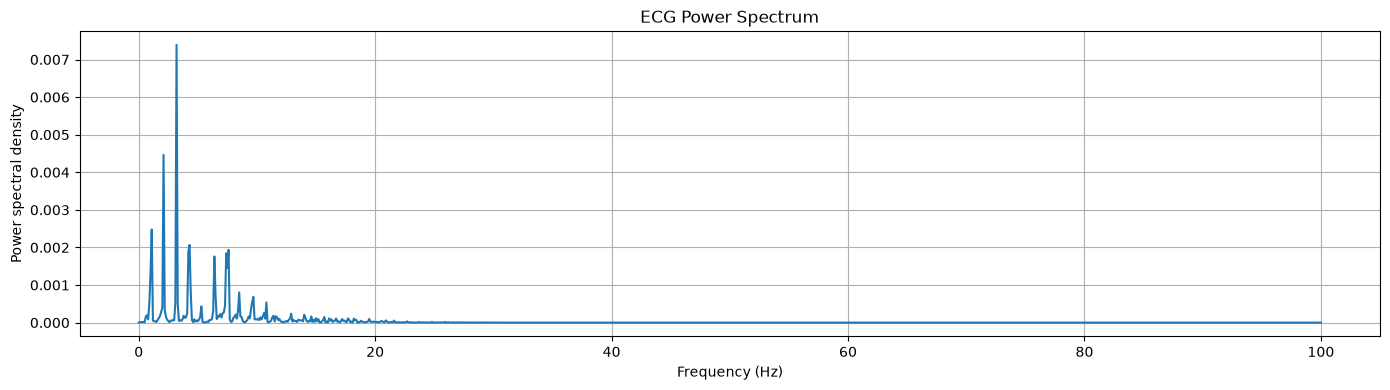

In [6]:
frequencies, power = periodogram(
    cleaned,
    fs=fs,
    detrend="constant"
)

mask = frequencies <= 100

plt.figure(figsize=(14, 4))
plt.plot(frequencies[mask], power[mask])
plt.title("ECG Power Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power spectral density")
plt.grid(True)
plt.tight_layout()
plt.show()


## Feature-extraction functions

In [7]:
def fill_missing_values(signal):
    signal = np.asarray(signal, dtype=float)
    valid = np.isfinite(signal)

    if valid.sum() == 0:
        raise ValueError("Signal contains no valid values.")

    if not np.all(valid):
        signal = np.interp(
            np.arange(len(signal)),
            np.flatnonzero(valid),
            signal[valid]
        )

    return signal


def estimate_qrs_duration(cleaned_signal, rpeaks, sampling_rate):
    if len(rpeaks) < 3:
        return np.nan

    try:
        _, waves = nk.ecg_delineate(
            cleaned_signal,
            rpeaks,
            sampling_rate=sampling_rate,
            method="dwt"
        )

        onsets = np.asarray(
            waves.get("ECG_R_Onsets", []),
            dtype=float
        )

        offsets = np.asarray(
            waves.get("ECG_R_Offsets", []),
            dtype=float
        )

        durations = []

        for onset, offset in zip(onsets, offsets):
            if (
                np.isfinite(onset)
                and np.isfinite(offset)
                and offset > onset
            ):
                duration_ms = (
                    (offset - onset)
                    / sampling_rate
                    * 1000
                )

                if 20 <= duration_ms <= 300:
                    durations.append(duration_ms)

        return (
            float(np.median(durations))
            if durations
            else np.nan
        )

    except Exception:
        return np.nan


In [8]:
def extract_ecg_features(record_path, label=None, target_fs=400):
    features = {
        "record_path": record_path,
        "label": label,
        "status": "failed"
    }

    try:
        record = wfdb.rdrecord(record_path)

        signals = np.asarray(record.p_signal, dtype=float)
        original_fs = int(record.fs)
        lead_names = list(record.sig_name)

        lead_index = (
            lead_names.index("II")
            if "II" in lead_names
            else min(1, signals.shape[1] - 1)
        )

        lead = fill_missing_values(
            signals[:, lead_index]
        )

        if original_fs != target_fs:
            lead = resample_poly(
                lead,
                target_fs,
                original_fs
            )

        fs_used = target_fs

        cleaned_signal = nk.ecg_clean(
            lead,
            sampling_rate=fs_used,
            method="neurokit"
        )

        _, peak_info = nk.ecg_peaks(
            cleaned_signal,
            sampling_rate=fs_used,
            method="neurokit"
        )

        peaks = np.asarray(
            peak_info["ECG_R_Peaks"],
            dtype=int
        )

        features.update({
            "original_sampling_rate": original_fs,
            "sampling_rate_used": fs_used,
            "duration_seconds": len(lead) / fs_used,
            "number_rpeaks": len(peaks),
            "signal_mean": float(np.mean(cleaned_signal)),
            "signal_std": float(np.std(cleaned_signal)),
            "signal_range": float(np.ptp(cleaned_signal)),
            "mean_rr_ms": np.nan,
            "sdnn_ms": np.nan,
            "rmssd_ms": np.nan,
            "heart_rate_bpm": np.nan
        })

        if len(peaks) >= 2:
            rr_ms = np.diff(peaks) / fs_used * 1000

            features["mean_rr_ms"] = float(
                np.mean(rr_ms)
            )

            features["heart_rate_bpm"] = float(
                60000 / np.mean(rr_ms)
            )

            if len(rr_ms) >= 2:
                features["sdnn_ms"] = float(
                    np.std(rr_ms, ddof=1)
                )

                features["rmssd_ms"] = float(
                    np.sqrt(
                        np.mean(np.diff(rr_ms) ** 2)
                    )
                )

        features["qrs_duration_ms"] = estimate_qrs_duration(
            cleaned_signal,
            peaks,
            fs_used
        )

        frequencies, power = periodogram(
            cleaned_signal,
            fs=fs_used,
            detrend="constant"
        )

        total_power = np.trapezoid(
            power,
            frequencies
        )

        qrs_mask = (
            (frequencies >= 5)
            & (frequencies <= 40)
        )

        qrs_band_power = np.trapezoid(
            power[qrs_mask],
            frequencies[qrs_mask]
        )

        features["total_spectral_power"] = float(total_power)
        features["qrs_band_power"] = float(qrs_band_power)

        features["qrs_power_ratio"] = (
            float(qrs_band_power / total_power)
            if total_power > 0
            else np.nan
        )

        features["status"] = "success"

    except Exception as error:
        features["error"] = str(error)

    return features


## Test feature extraction

In [9]:
test_features = extract_ecg_features(
    example_path,
    label=0
)

pd.Series(test_features)


record_path               data/ptbxl_wfdb/00000/00001_hr
label                                                  0
status                                           success
original_sampling_rate                               500
sampling_rate_used                                   400
duration_seconds                                    10.0
number_rpeaks                                         10
signal_mean                                     0.000605
signal_std                                      0.069364
signal_range                                    0.416213
mean_rr_ms                                         940.0
sdnn_ms                                        18.708287
rmssd_ms                                       25.078003
heart_rate_bpm                                 63.829787
qrs_duration_ms                                   178.75
total_spectral_power                            0.004811
qrs_band_power                                  0.002243
qrs_power_ratio                

## Balanced SaMi-Trop and PTB-XL extraction

In [10]:
number_per_class = min(
    100,
    len(sami_records),
    len(ptb_records)
)

print("Records per class:", number_per_class)

all_features = []

if number_per_class == 0:
    print(
        "Both SaMi-Trop and PTB-XL prepared records are required."
    )

else:
    for index, record_path in enumerate(
        sami_records[:number_per_class],
        start=1
    ):
        result = extract_ecg_features(
            record_path,
            label=1
        )
        result["dataset"] = "SaMi-Trop"
        all_features.append(result)

        if index % 10 == 0:
            print(
                f"Processed {index}/{number_per_class} "
                "SaMi-Trop records"
            )

    for index, record_path in enumerate(
        ptb_records[:number_per_class],
        start=1
    ):
        result = extract_ecg_features(
            record_path,
            label=0
        )
        result["dataset"] = "PTB-XL"
        all_features.append(result)

        if index % 10 == 0:
            print(
                f"Processed {index}/{number_per_class} "
                "PTB-XL records"
            )


Records per class: 100


Processed 10/100 SaMi-Trop records


Processed 20/100 SaMi-Trop records


Processed 30/100 SaMi-Trop records


Processed 40/100 SaMi-Trop records


...

Processed 60/100 PTB-XL records


Processed 70/100 PTB-XL records


Processed 80/100 PTB-XL records


Processed 90/100 PTB-XL records


Processed 100/100 PTB-XL records


In [11]:
if all_features:
    features_df = pd.DataFrame(all_features)

    successful_df = features_df[
        features_df["status"] == "success"
    ].copy()

    successful_df.to_csv(
        "week4_ecg_features.csv",
        index=False
    )

    print("Saved week4_ecg_features.csv")
    print("Successful records:", len(successful_df))
    print(successful_df["dataset"].value_counts())

    display(successful_df.head())

else:
    successful_df = pd.DataFrame()
    print("No balanced feature table was created.")


Saved week4_ecg_features.csv
Successful records: 200
dataset
SaMi-Trop    100
PTB-XL       100
Name: count, dtype: int64


,record_path,label,status,original_sampling_rate,sampling_rate_used,duration_seconds,number_rpeaks,signal_mean,signal_std,signal_range,mean_rr_ms,sdnn_ms,rmssd_ms,heart_rate_bpm,qrs_duration_ms,total_spectral_power,qrs_band_power,qrs_power_ratio,dataset
0,data/samitrop_wfdb/100726,1,success,400,400,7.335,7,0.000231,0.103140,0.985702,1109.583333,22.550868,31.898276,54.074352,132.5,0.010638,0.008743,0.821868,SaMi-Trop
1,data/samitrop_wfdb/101191,1,success,400,400,7.335,7,-0.000946,0.106088,0.934169,1046.666667,7.011895,12.399597,57.324841,220.0,0.011255,0.007012,0.623046,SaMi-Trop
2,data/samitrop_wfdb/101193,1,success,400,400,7.335,8,0.003463,0.214373,1.396693,949.285714,5.721721,6.373774,63.205418,115.0,0.045956,0.019603,0.426560,SaMi-Trop
3,data/samitrop_wfdb/101282,1,success,400,400,7.335,7,0.001000,0.126772,0.871173,985.416667,10.418333,8.587782,60.887949,182.5,0.016071,0.005627,0.350140,SaMi-Trop
4,data/samitrop_wfdb/101842,1,success,400,400,7.335,8,0.001624,0.286154,2.245470,918.571429,12.571226,16.007811,65.318818,175.0,0.081884,0.054613,0.666953,SaMi-Trop


## Feature distributions

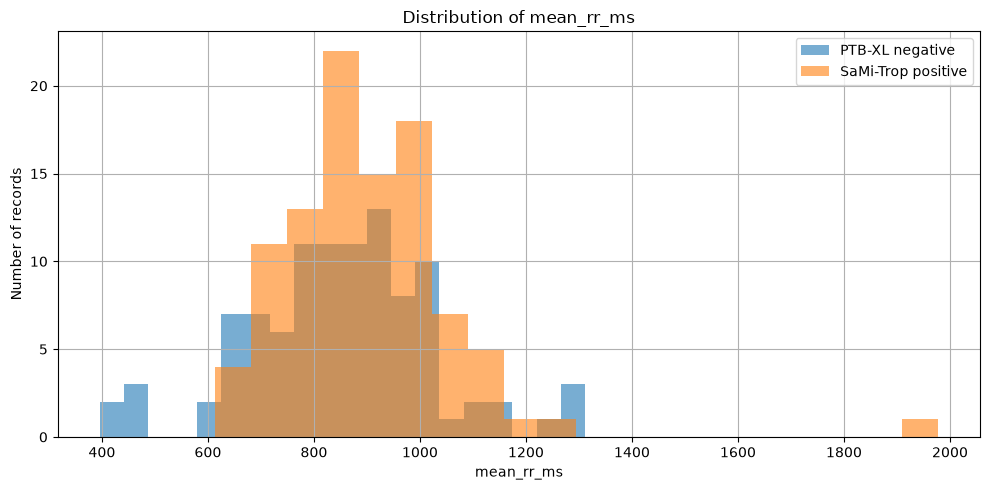

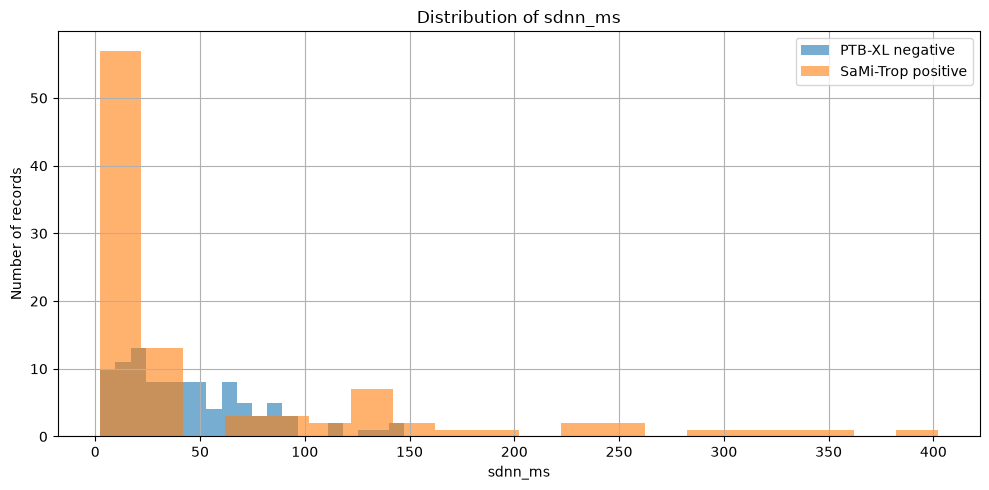

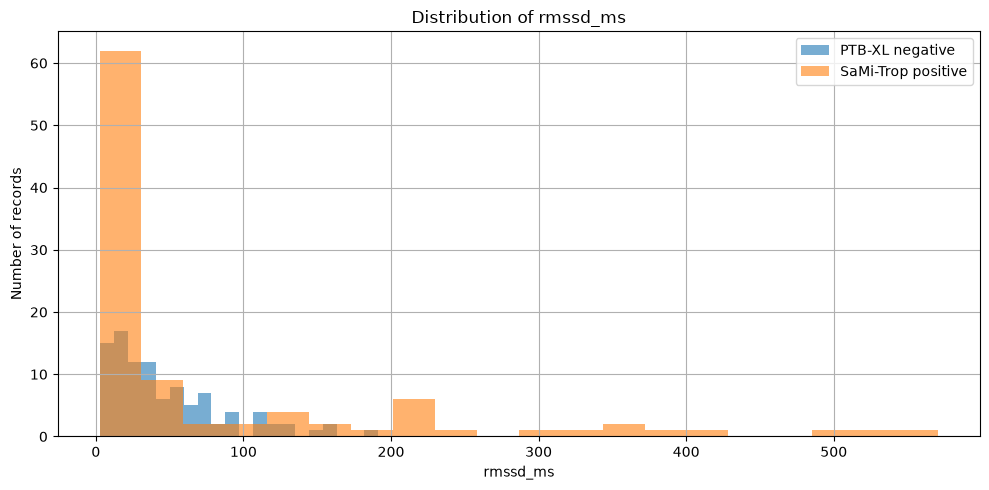

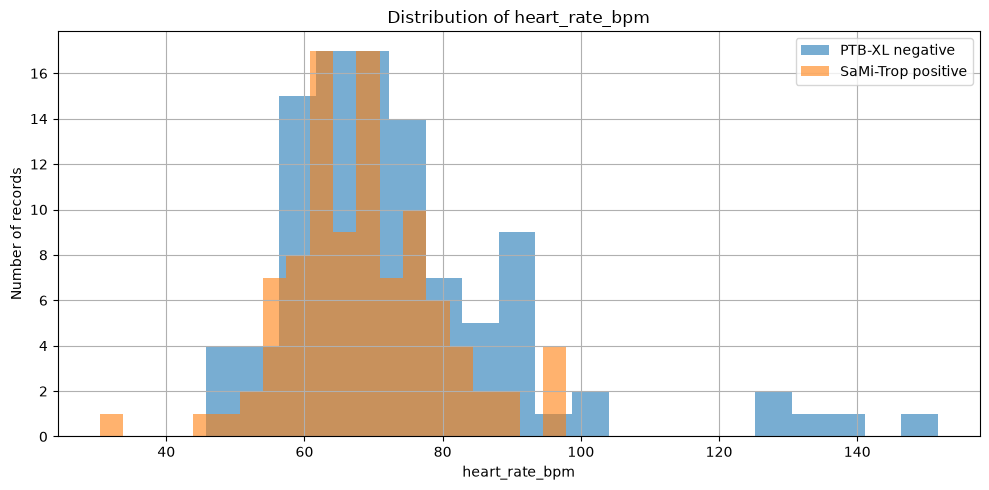

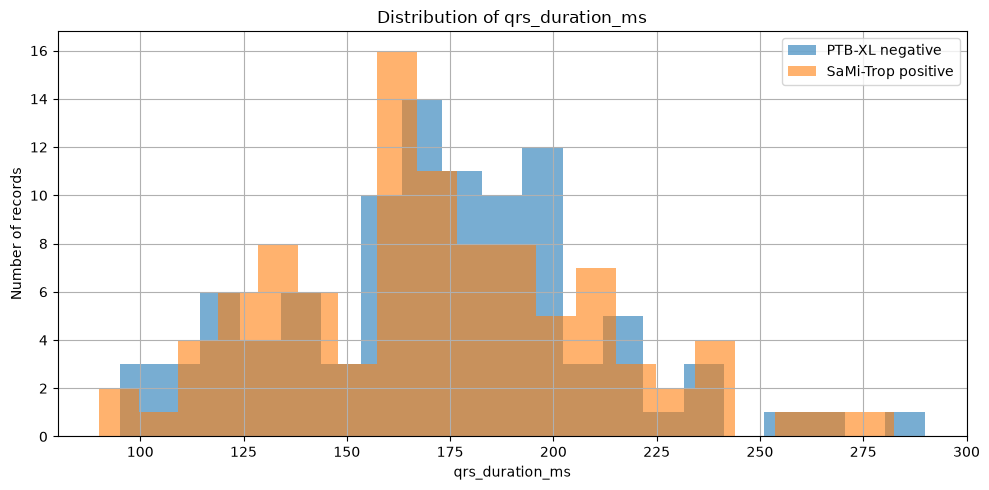

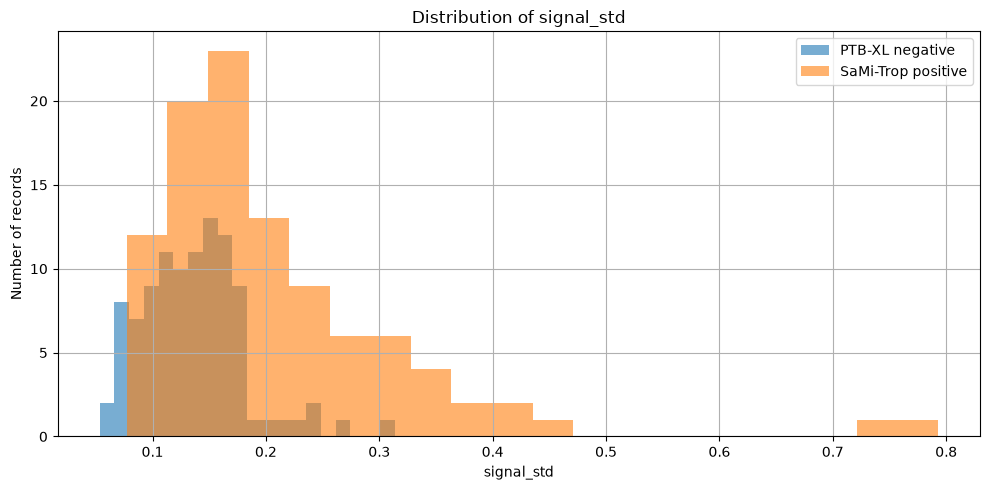

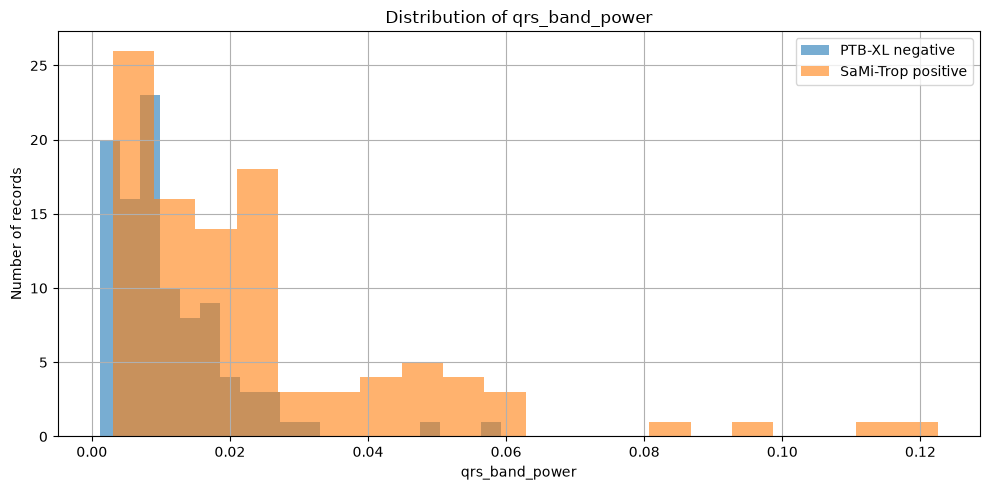

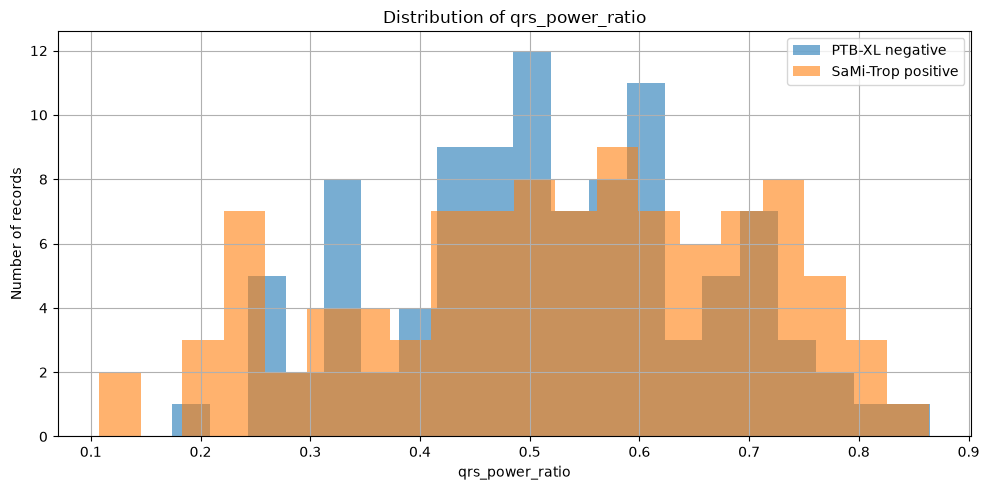

In [12]:
def plot_feature_distribution(dataframe, feature_name):
    positive = dataframe.loc[
        dataframe["label"] == 1,
        feature_name
    ].dropna()

    negative = dataframe.loc[
        dataframe["label"] == 0,
        feature_name
    ].dropna()

    if len(positive) == 0 or len(negative) == 0:
        print("Skipping", feature_name)
        return

    plt.figure(figsize=(10, 5))
    plt.hist(
        negative,
        bins=20,
        alpha=0.6,
        label="PTB-XL negative"
    )
    plt.hist(
        positive,
        bins=20,
        alpha=0.6,
        label="SaMi-Trop positive"
    )

    plt.title(f"Distribution of {feature_name}")
    plt.xlabel(feature_name)
    plt.ylabel("Number of records")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


features_to_plot = [
    "mean_rr_ms",
    "sdnn_ms",
    "rmssd_ms",
    "heart_rate_bpm",
    "qrs_duration_ms",
    "signal_std",
    "qrs_band_power",
    "qrs_power_ratio"
]

if not successful_df.empty:
    for feature in features_to_plot:
        plot_feature_distribution(
            successful_df,
            feature
        )
else:
    print("Feature plots require records from both groups.")


## Observations

The R-peak markers should align with the main QRS peaks.

SDNN and RMSSD may show substantial overlap because the ECG recordings are very short. QRS duration may be more useful because Chagas disease can cause cardiac conduction abnormalities. Final conclusions should be based on the actual feature plots rather than assumptions.

These results are exploratory and are not suitable for clinical diagnosis.
